In [2]:
pip install mediapipe

     |████████████████████████████████| 32.7 MB 1.2 MB/s 


In [23]:
import cv2
import mediapipe as mp
mp_face_detection = mp.solutions.face_detection
mp_drawing = mp.solutions.drawing_utils

# For static images:
IMAGE_FILES = ["/content/drive/MyDrive/Extra Work/nita.jpg"]
with mp_face_detection.FaceDetection(
    model_selection=1, min_detection_confidence=0.5) as face_detection:
  for idx, file in enumerate(IMAGE_FILES):
    image = cv2.imread(file)
    
    # Convert the BGR image to RGB and process it with MediaPipe Face Detection.
    results = face_detection.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    # Draw face detections of each face.
    if not results.detections:
      continue
    annotated_image = image.copy()
    for detection in results.detections:
      #print('Nose tip:')
      #print(mp_face_detection.get_key_point(detection, mp_face_detection.FaceKeyPoint.NOSE_TIP))
      x,y = mp_face_detection.get_key_point(detection, mp_face_detection.FaceKeyPoint.NOSE_TIP)
      mp_drawing.draw_detection(annotated_image, detection)
      cv2.putText(annotated_image, name,(x,y),cv2.FONT_HERSHEY_DUPLEX, 1.2, (0, 255, 0), 2)
      mp_drawing.draw_detection(annotated_image, detection)
    resize_and_show(annotated_image)
      
   # cv2.imwrite('/tmp/annotated_image' + str(idx) + '.png', annotated_image)

ValueError: ignored

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import cv2
import mediapipe as mp

In [7]:
mp_face_detection = mp.solutions.face_detection
mp_drawing = mp.solutions.drawing_utils

In [8]:
from google.colab import files
uploaded_short_range = files.upload()

Saving nita1.jpg to nita1.jpg


In [ ]:
from google.colab import files
uploaded_full_range = files.upload()

Saving face2.jpg to face2.jpg


nita1.jpg


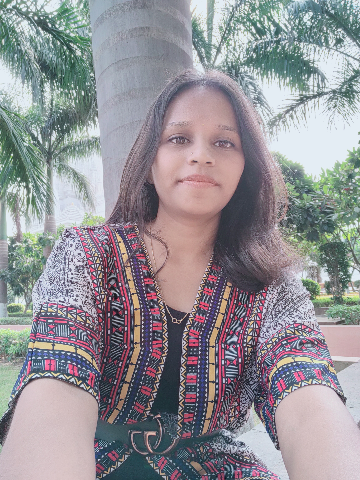

NameError: ignored

In [9]:
import cv2
from google.colab.patches import cv2_imshow
import math
import numpy as np
 
DESIRED_HEIGHT = 480
DESIRED_WIDTH = 480
def resize_and_show(image):
  h, w = image.shape[:2]
  if h < w:
    img = cv2.resize(image, (DESIRED_WIDTH, math.floor(h/(w/DESIRED_WIDTH))))
  else:
    img = cv2.resize(image, (math.floor(w/(h/DESIRED_HEIGHT)), DESIRED_HEIGHT))
  cv2_imshow(img)
 
# Preview the images.
short_range_images = {name: cv2.imread(name) for name in uploaded_short_range.keys()}
for name, image in short_range_images.items():
  print(name)   
  resize_and_show(image)
 
#full_range_images = {name: cv2.imread(name) for name in uploaded_full_range.keys()}
#for name, image in full_range_images.items():
  #print(name)   
  #resize_and_show(image)

Face detections of nita1.jpg:


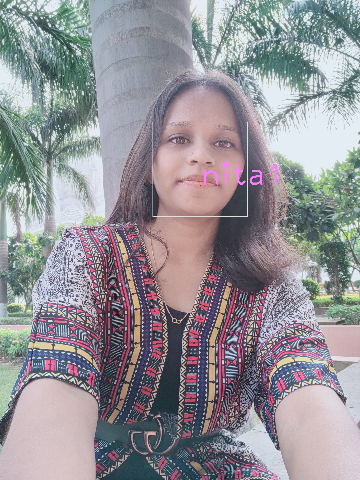

In [42]:
# Run MediaPipe Face Detection with short range model.

with mp_face_detection.FaceDetection(
    min_detection_confidence=0.5, model_selection=0) as face_detection:
  for name, image in short_range_images.items():
    # Convert the BGR image to RGB and process it with MediaPipe Face Detection.
    results = face_detection.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    (h, w) = image.shape[:2]
    # Draw face detections of each face.
    print(f'Face detections of {name}:')
    if not results.detections:
      continue
    annotated_image = image.copy()
    for detection in results.detections:
      #print('Nose tip:')
      #print(mp_face_detection.get_key_point(detection, mp_face_detection.FaceKeyPoint.NOSE_TIP))
      a=mp_face_detection.get_key_point(detection, mp_face_detection.FaceKeyPoint.MOUTH_CENTER)
    
      mp_drawing.draw_detection(annotated_image, detection)
      cv2.putText(annotated_image, name[:name.index('.')],(int(a.x*w),int(a.y*h)),cv2.FONT_HERSHEY_PLAIN, 20, (255, 123, 255), 20)
      mp_drawing.draw_detection(annotated_image, detection)
    resize_and_show(annotated_image)
      
    

Face detections of face2.jpg:


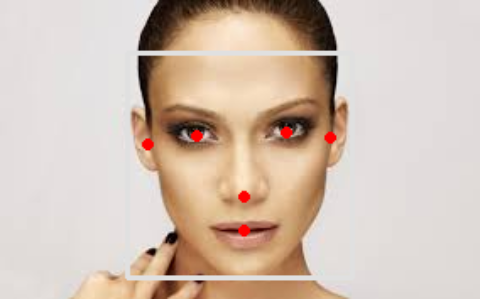

In [ ]:
# Run MediaPipe Face Detection with long range model.

with mp_face_detection.FaceDetection(
    min_detection_confidence=0.5, model_selection=1) as face_detection:
  for name, image in full_range_images.items():
    # Convert the BGR image to RGB and process it with MediaPipe Face Detection.
    results = face_detection.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    # Draw face detections of each face.
    print(f'Face detections of {name}:')
    if not results.detections:
      continue
    annotated_image = image.copy()
    for detection in results.detections:
      mp_drawing.draw_detection(annotated_image, detection)
    resize_and_show(annotated_image)